# NASA Battery Data Visualization by Entity

This notebook creates visualizations for NASA battery dataset, showing feature trends for each battery entity separately. It loads preprocessed data from individual entity folders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def load_nasa_processed_data():
    """
    Load preprocessed NASA battery data from individual entity folders
    """
    base_folder = "datasets/NASA/processed"
    
    #  Get all battery folders
    battery_folders = [f for f in os.listdir(base_folder) 
                       if os.path.isdir(os.path.join(base_folder, f)) and f.startswith('B00')]
    
    battery_data = {}
    
    for battery_id in battery_folders:
        battery_folder = os.path.join(base_folder, battery_id)
        
        print(f"Loading data for battery {battery_id}...")
        
         # Load train data
        train_path = os.path.join(battery_folder, "train.pkl")
        test_path = os.path.join(battery_folder, "test.pkl")
        
        if os.path.exists(train_path) and os.path.exists(test_path):
            with open(train_path, 'rb') as f:
                train_data = pickle.load(f)
                
            with open(test_path, 'rb') as f:
                test_data = pickle.load(f)
                
            # // Combine train and test data for visualization
            combined_data = np.concatenate([train_data, test_data], axis=0)
            
            # // Create DataFrame with feature names
            feature_names = ['capacity', 'voltage_measured', 'current_measured', 
                           'temperature_measured', 'current_charge', 'voltage_charge']
            df = pd.DataFrame(data=combined_data, columns=feature_names)
            
            battery_data[battery_id] = df
            
            print(f"Loaded {battery_id} data with shape: {combined_data.shape}")
        else:
            print(f"Missing data files for battery {battery_id}")
    
    return battery_data

In [3]:
def visualize_battery_features(battery_data):
    """
    Create feature trend visualization for each battery entity
    """
    # // Define features to visualize
    features = ['capacity', 'voltage_measured', 'current_measured', 
                'temperature_measured', 'current_charge', 'voltage_charge']
    
    # // Create separate plots for each battery
    for battery_id, df in battery_data.items():
        fig, axes = plt.subplots(len(features), 1, figsize=(15, 3*len(features)))
        if len(features) == 1:
            axes = [axes]
            
        fig.suptitle(f'Battery {battery_id} Feature Trends', fontsize=16)
        
        # // Plot each feature
        for idx, feature in enumerate(features):
            axes[idx].plot(df.index, df[feature], linewidth=1)
            axes[idx].set_title(f'{feature}')
            axes[idx].set_xlabel('Time')
            axes[idx].set_ylabel(feature)
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [4]:
# // Load NASA battery data
battery_data = load_nasa_processed_data()

Loading data for battery B0049...
Loaded B0049 data with shape: (5934, 6)
Loading data for battery B0050...
Loaded B0050 data with shape: (5307, 6)
Loading data for battery B0051...
Loaded B0051 data with shape: (5934, 6)
Loading data for battery B0052...
Loaded B0052 data with shape: (1165, 6)


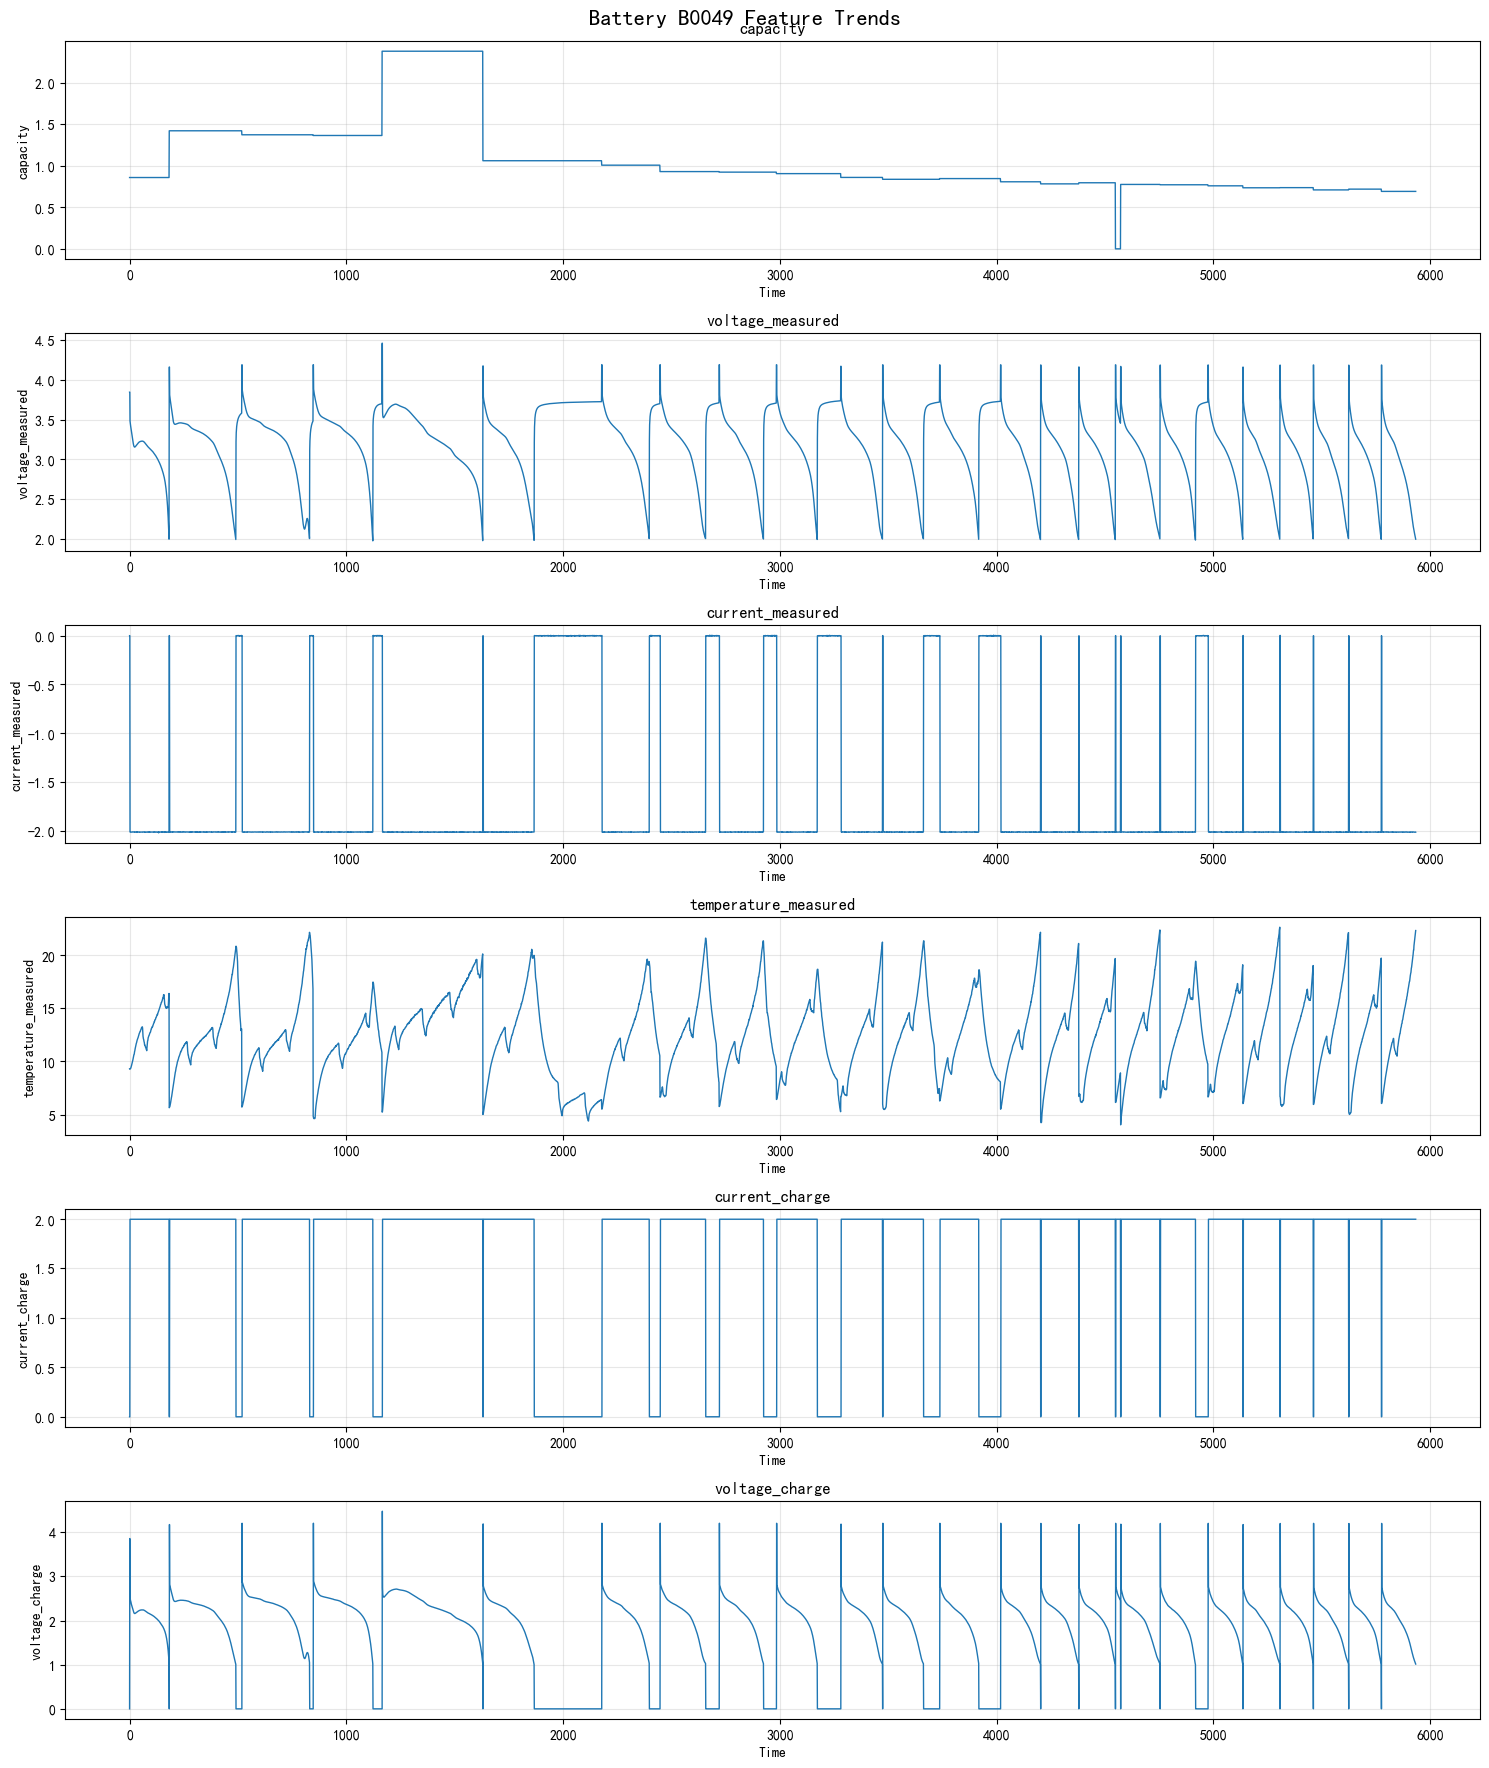

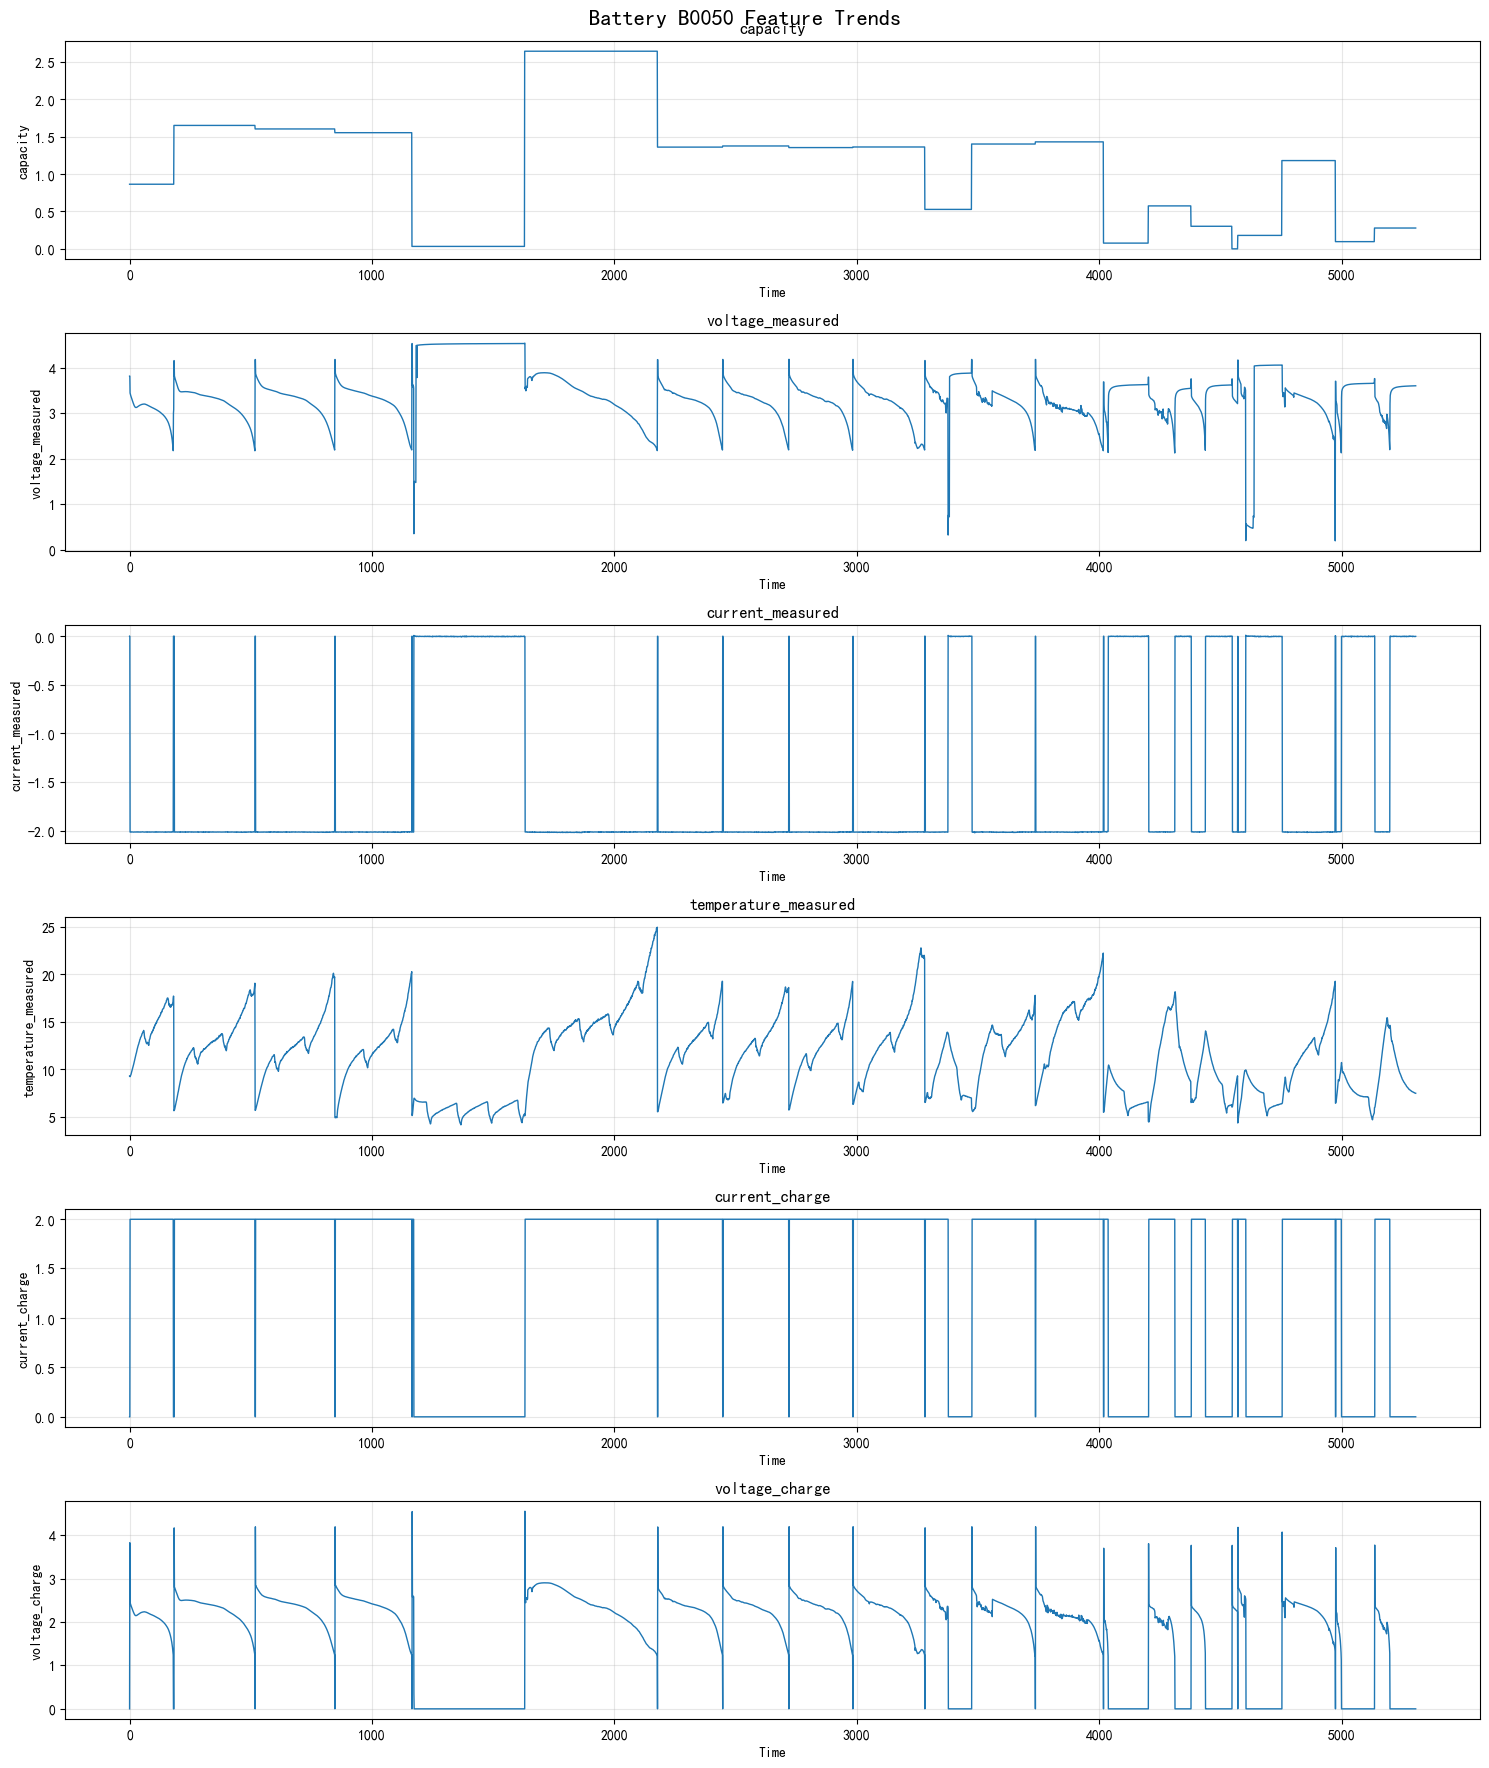

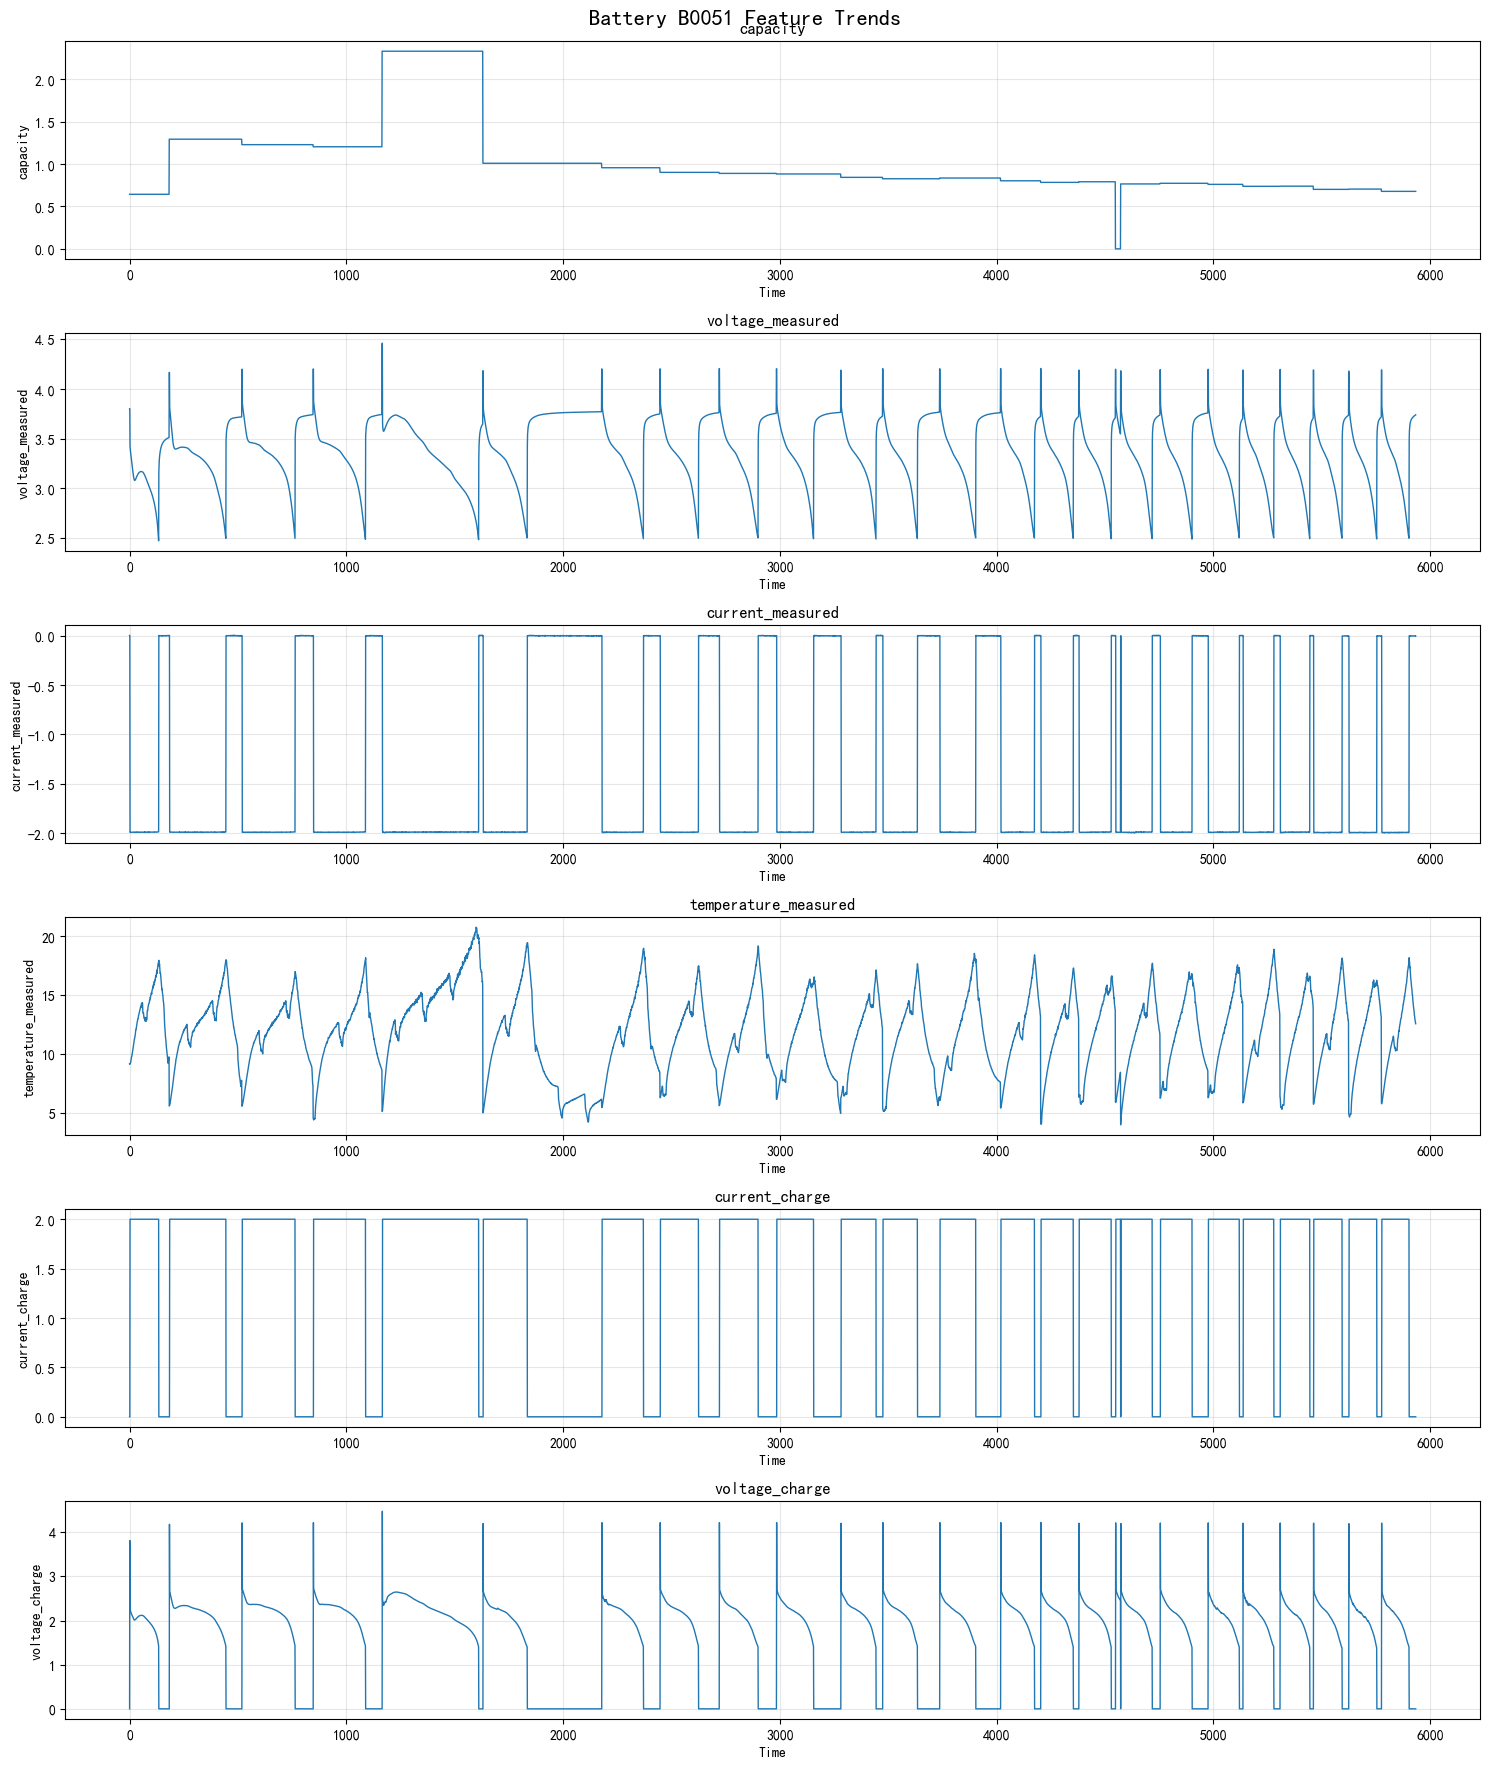

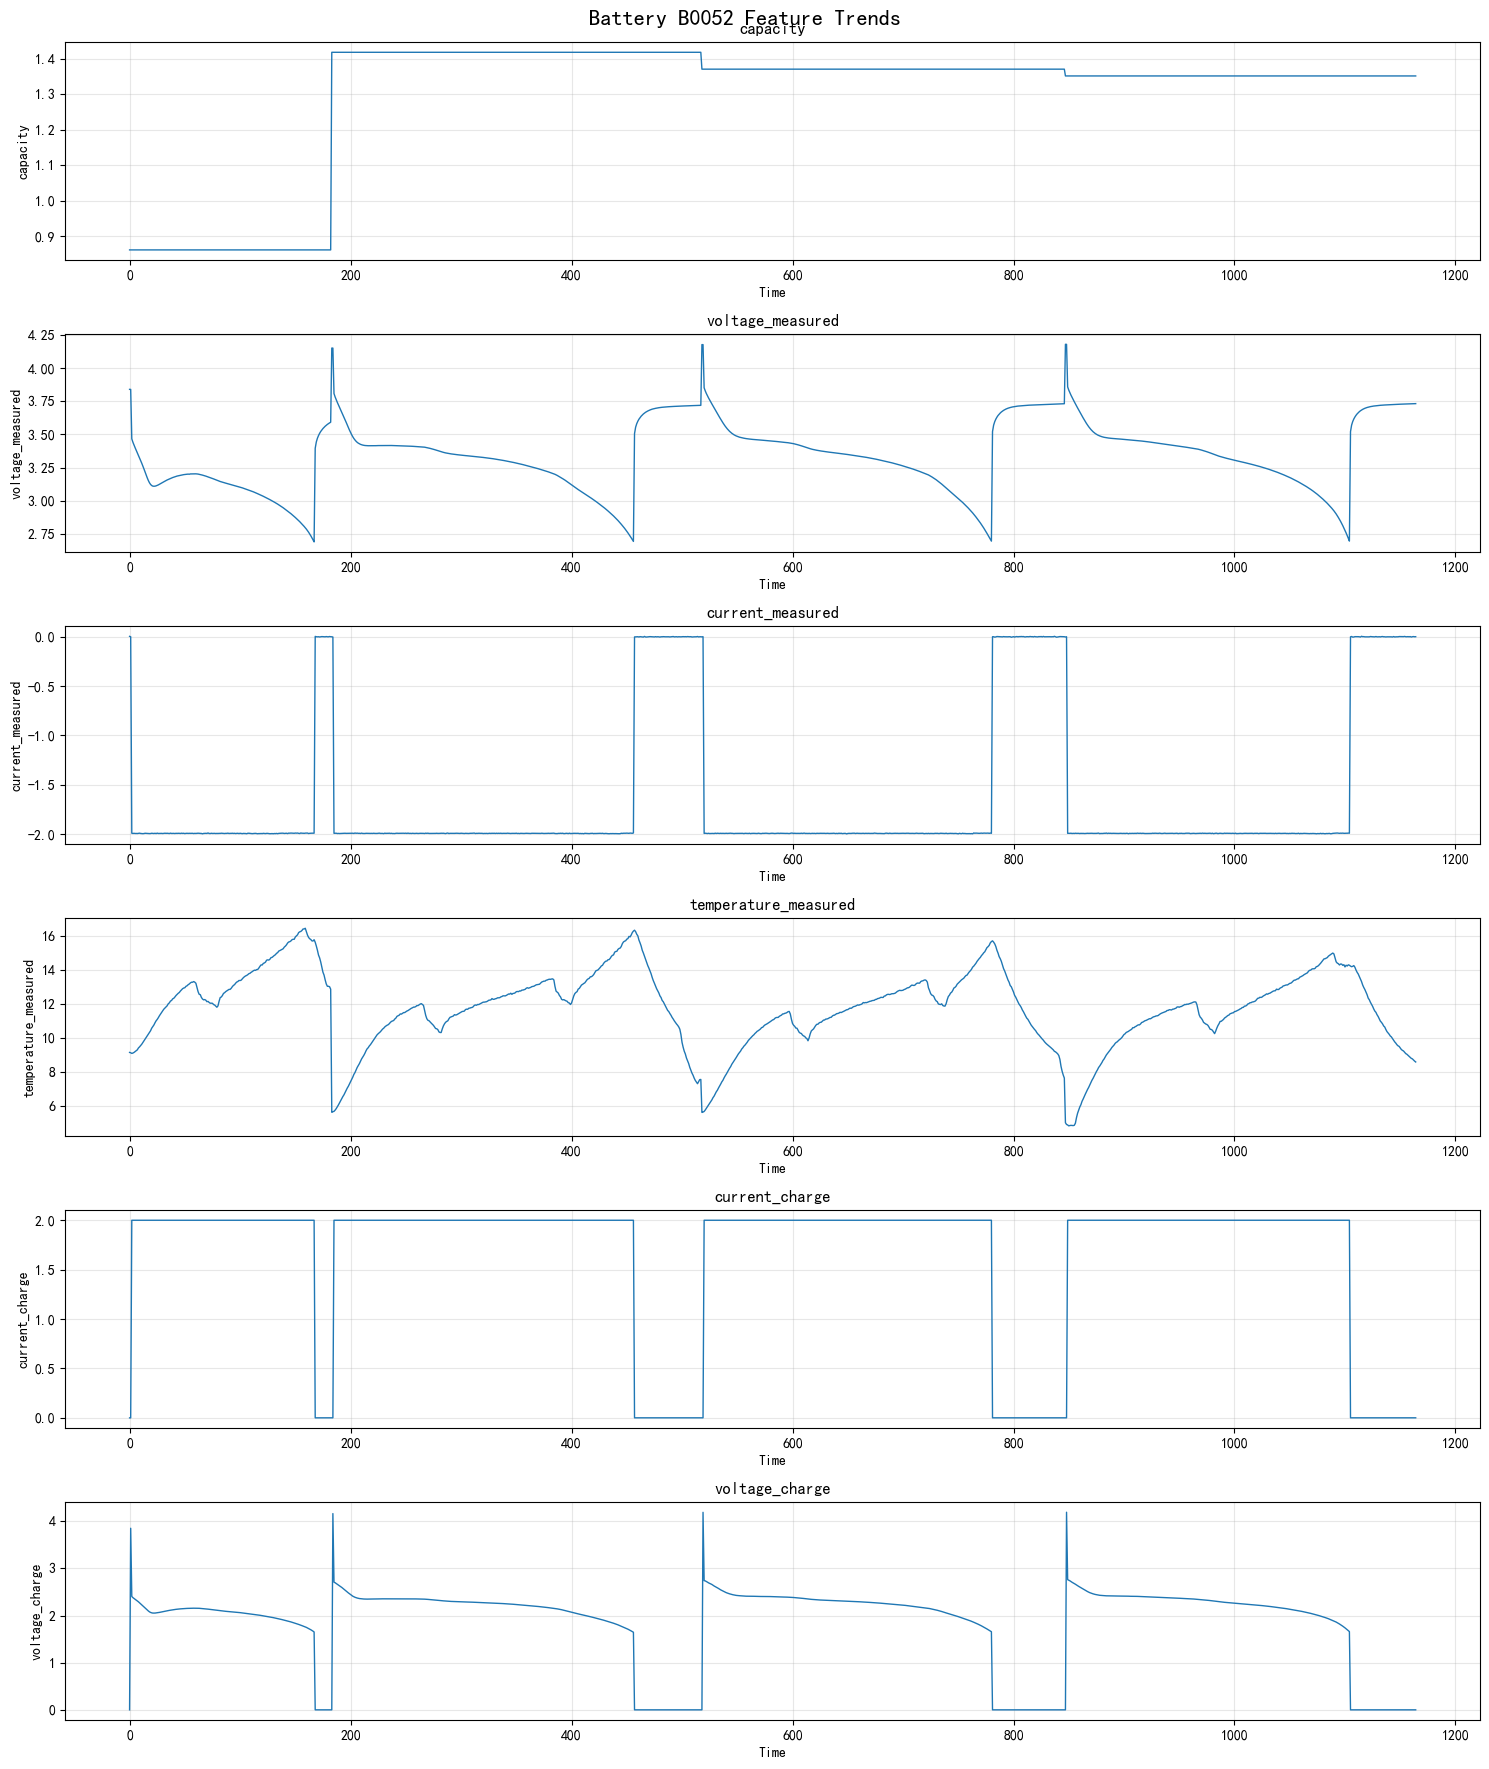

In [5]:
# // Visualize feature trends for each battery
visualize_battery_features(battery_data)